## Artéfact à la YASA

In [1]:
import yasa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white', font_scale=1.2)
import mne
import io


In [ ]:

raw = mne.io.read_raw_edf('D:/EEG/raw/MN143/MN143_240115E-A.edf', preload=True)
data = raw.get_data()
chan = raw.ch_names
sfreq = raw.info['sfreq'] 

hypno_path = 'D:/EEG/raw/MN143/MN143_240115E-AhypnoEXP.txt'
hypno_df = pd.read_csv(hypno_path, sep="\t", names=["start", "time", "stage", "code"])

# Convertir les stades texte en code YASA
stage_map = {
    "W": 0, "N1": 1, "N2": 2, "N3": 3, "REM": 4
}

print(f"{data.shape[0]} canaux, {data.shape[1]} points à {sfreq} Hz")
chan
(data*10**6).round(4)

Extracting EDF parameters from D:\EEG\raw\MN143\MN143_240115E-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6855679  =      0.000 ... 26779.996 secs...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_25744\873819642.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf('D:/EEG/raw/MN143/MN143_240115E-A.edf', preload=True)


33 canaux, 6855680 points à 256.0 Hz


array([[ 8.95000000e-02,  8.95000000e-02,  8.95000000e-02, ...,
         1.25381300e+02,  9.84400000e-01, -8.74358000e+01],
       [ 8.95000000e-02,  8.95000000e-02,  8.95000000e-02, ...,
         1.40416300e+02,  2.80117000e+01, -6.02296000e+01],
       [ 8.95000000e-02,  8.95000000e-02,  8.95000000e-02, ...,
         6.61362000e+01, -5.71868000e+01, -1.48112800e+02],
       ...,
       [ 1.89211870e+03,  1.89211870e+03,  1.89211870e+03, ...,
         3.50988022e+06,  3.51366445e+06,  3.51744869e+06],
       [ 8.94941634e+04,  8.94941634e+04,  8.94941634e+04, ...,
         8.94941634e+04,  8.94941634e+04,  8.94941634e+04],
       [-3.66216500e+02, -3.66216500e+02, -3.66216500e+02, ...,
         1.33669032e+05,  1.32936599e+05,  1.32936599e+05]],
      shape=(33, 6855680))

08-Jul-25 16:50:16 | WARNING | Hypnogram is SHORTER than data by 41796.80 seconds. Padding hypnogram with last value to match data.size.
C:\Users\Dessalines\AppData\Local\Temp\ipykernel_25744\1732259710.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


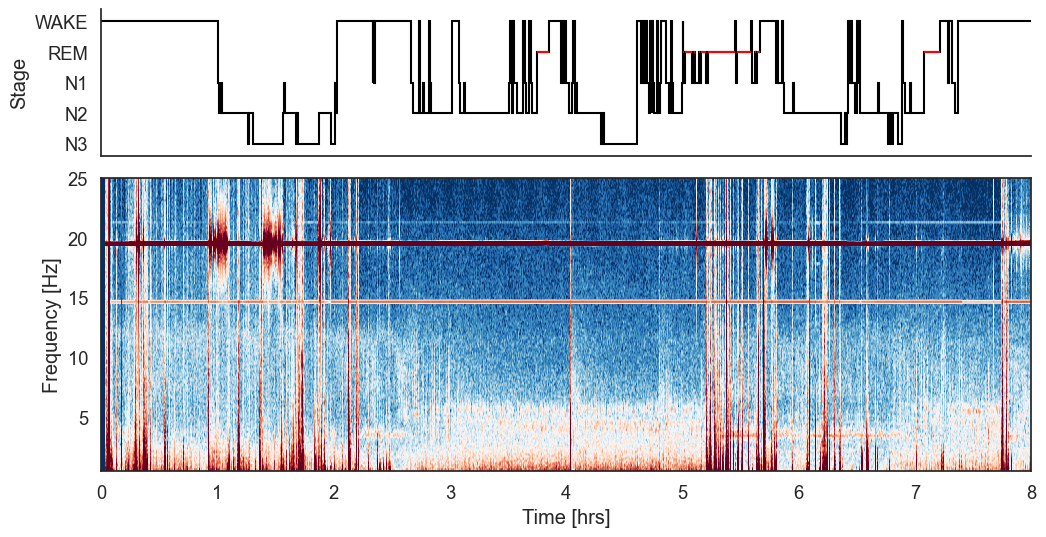

In [3]:
# Plot hypnogram and spectrogram on Fz
# We should see a warning because of the flat data at the end
sf = 100.
hypno_int = hypno_df["stage"].str.strip().map(stage_map).fillna(-2).astype(int)
hypno_vec = yasa.hypno_upsample_to_data(hypno_int.values, 1/30, data[2], sf)
fig = yasa.plot_spectrogram(data[2], sf, hypno=hypno_vec)

# Récupère les axes de la figure
ax0, ax1 = fig.axes  # ax0 = hypnogram, ax1 = spectrogramme

# Limite d'heure
ax0.set_xlim(0, 8)
ax1.set_xlim(0, 8)

plt.tight_layout()
plt.show()

Attention, on remarque que pour beaucoup, on obtiens le message warning.

Je pense que pour exploiter au mieux l'outils, il faudrait un hypnogramme aussi long que le spectogramme (.edf)

## C'est parti

In [4]:
art, zscores = yasa.art_detect(data, sf, window=5, method='covar', threshold=3)
art.shape, zscores.shape

08-Jul-25 16:50:33 | WARNING | Flat channel(s) were found and removed in data.


((13711,), (13711,))

In [5]:
# Art is an aray of 0 and 1, where 0 indicates a clean (or good epoch)  and 1 indicates an artifact epoch
print(art)
print(f'{art.sum()} / {art.size} epochs rejected.')

[ True  True  True ... False False False]
875 / 13711 epochs rejected.


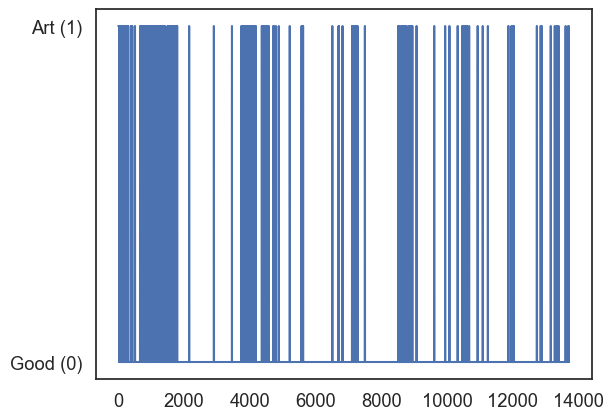

In [6]:
# Plot the artifact vector
plt.plot(art);
plt.yticks([0, 1], labels=['Good (0)', 'Art (1)']);

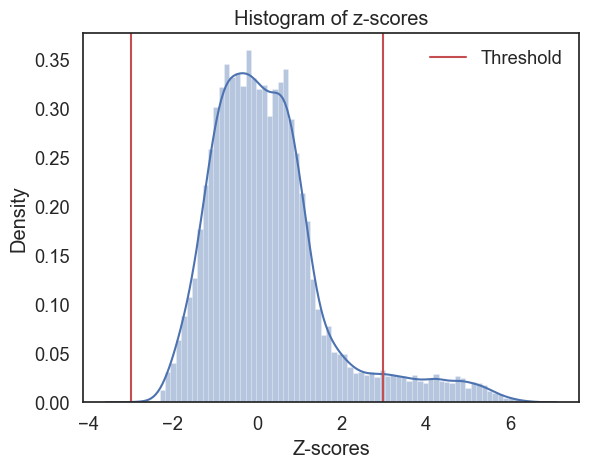

In [7]:
sns.histplot(zscores, stat='density', alpha=0.4, edgecolor=(1, 1, 1, 0.4), kde=True, kde_kws=dict(cut=3))
plt.title('Histogram of z-scores')
plt.xlabel('Z-scores')
plt.ylabel('Density')
plt.axvline(3, color='r', label='Threshold')
plt.axvline(-3, color='r')
plt.legend(frameon=False);

In [8]:

from scipy.special import erf
threshold = 3
perc_expected_rejected = (1 - erf(threshold / np.sqrt(2))) * 100
print(f'{perc_expected_rejected:.2f}% of all epochs are expected to be rejected.')

0.27% of all epochs are expected to be rejected.


In [9]:
# Actual
(art.sum() / art.size) * 100
print(f'{(art.sum() / art.size) * 100:.2f}% of all epochs were actually rejected.')

6.38% of all epochs were actually rejected.


In [10]:
# Merge the artifcat vector with the hypnogram
# The resolution of art is 5 seconds, so its sampling frequency is 1/5 (= 0.2 Hz)
sf_art = 1 / 5
art_up = yasa.hypno_upsample_to_data(art, sf_art, data, sf)
art_up.shape, hypno_vec.shape

08-Jul-25 16:52:53 | WARNING | Hypnogram is SHORTER than data by 1.80 seconds. Padding hypnogram with last value to match data.size.


((6855680,), (6855680,))

Now that hypno and art_up have the same size, we can easily merge them. Below, we mark as artifact (code = -1) all the 5-seconds epochs that were automatically rejected:

In [11]:
# Add -1 to hypnogram where artifacts were detected
hypno_with_art = hypno_vec.copy()
hypno_with_art[art_up] = -1

# Proportion of each stage in ``hypno_with_art``
pd.Series(hypno_with_art).value_counts(normalize=True)

 0    0.699519
 2    0.131205
-1    0.063816
 3    0.042592
 4    0.032382
 1    0.030486
Name: proportion, dtype: float64

C:\Users\Dessalines\AppData\Local\Temp\ipykernel_25744\1452160442.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


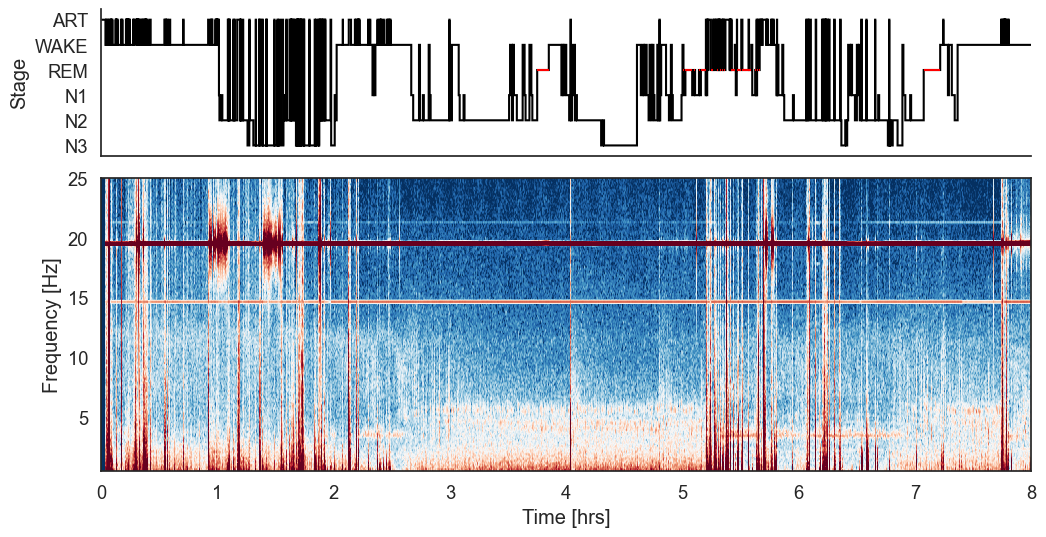

In [12]:
# Plot new hypnogram and spectrogram on Fz
fig = yasa.plot_spectrogram(data[2], sf, hypno=hypno_with_art)

# Récupère les axes de la figure
ax0, ax1 = fig.axes  # ax0 = hypnogram, ax1 = spectrogramme

# Limite d'heure
ax0.set_xlim(0, 8)
ax1.set_xlim(0, 8)

plt.tight_layout()
plt.show()

 ## The Riemannian Potato method:

 https://hal.archives-ouvertes.fr/hal-00781701/

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from pyriemann.estimation import Covariances
from pyriemann.utils.distance import distance_riemann
from pyriemann.utils.mean import mean_riemann


Fonction de détection Riemannian Potato

In [2]:
def riemannian_potato_detection(epochs, batch_size=500, alpha=0.01, init_duration=30, n_jobs=-1):
    """
    Détection d’artefacts EEG par la méthode Riemannian Potato.

    Args:
        epochs (mne.Epochs): époques EEG
        batch_size (int): taille des batches à traiter
        alpha (float): vitesse d’adaptation du centre
        init_duration (int): nombre d'époques initiales pour estimer la référence
        n_jobs (int): nombre de cœurs pour la parallélisation (–1 = tous)

    Returns:
        distances (np.ndarray): distances Riemanniennes
        artifact_mask (np.ndarray): booléen True = artefact
        threshold (float): seuil utilisé
    """
    def process_batch(batch_data, ref_cov):
        covs = Covariances().fit_transform(batch_data)
        dists = [distance_riemann(cov, ref_cov) for cov in covs]
        return covs, dists

    n_epochs = len(epochs)
    ref_cov = None
    distances = []

    for start in range(0, n_epochs, batch_size):
        stop = min(start + batch_size, n_epochs)
        batch = epochs[start:stop].get_data()

        if ref_cov is None:
            covs_init = Covariances().fit_transform(batch[:init_duration])
            covs_init = regularize_covs(covs_init)
            ref_cov = mean_riemann(covs_init, maxiter=100)
            continue

        n_chunks = min(n_jobs if n_jobs > 0 else 4, len(batch))
        chunk_size = max(1, len(batch) // n_chunks)

        results = Parallel(n_jobs=n_jobs)(
            delayed(process_batch)(batch[i:i + chunk_size], ref_cov)
            for i in range(0, len(batch), chunk_size)
        )

        for covs, dists in results:
            covs = regularize_covs(covs)
            for cov, dist in zip(covs, dists):
                distances.append(dist)
                if dist < (np.mean(distances) + 2.5 * np.std(distances)):
                    ref_cov = mean_riemann([ref_cov, cov])

    distances = np.array(distances)
    threshold = np.mean(distances) + 2.5 * np.std(distances)
    artifact_mask = distances > threshold

    return distances, artifact_mask, threshold

def regularize_covs(covs, reg=1e-5):
    return np.array([cov + reg * np.eye(cov.shape[0]) for cov in covs])



Chargement des données

In [3]:
raw = mne.io.read_raw_edf("D:/EEG/raw/BA152/231024E-B.edf", preload=True)
raw.pick_types(eeg=True)
raw.filter(1., 20., fir_design='firwin')


Extracting EDF parameters from D:\EEG\raw\BA152\231024E-B.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_10672\2612927897.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("D:/EEG/raw/BA152/231024E-B.edf", preload=True)


Reading 0 ... 6846207  =      0.000 ... 26742.996 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 845 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s
[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:    3.9s finished


<RawEDF | 231024E-B.edf, 33 x 6846208 (26743.0 s), ~1.68 GiB, data loaded>

Using matplotlib as 2D backend.


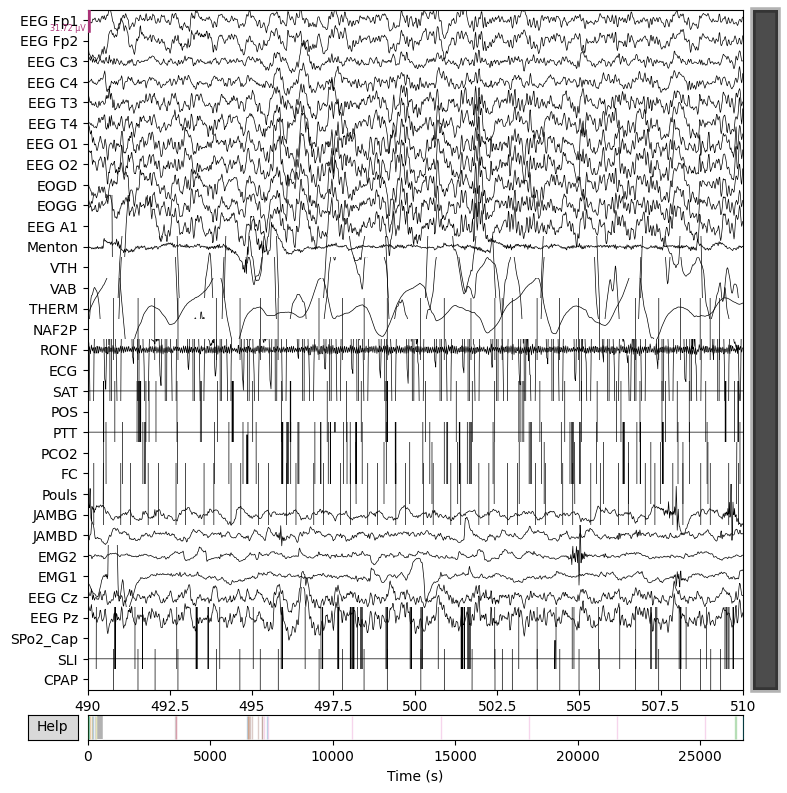

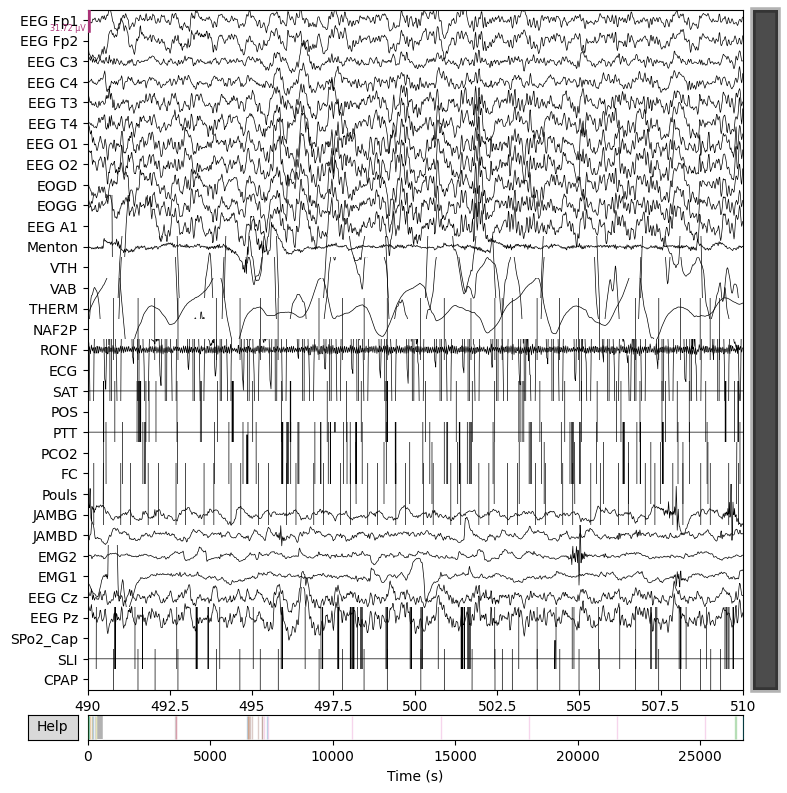

In [4]:
raw.plot(n_channels=35,start=490 ,duration= 20 , scalings='auto', show=False)

In [5]:
# On fait les epochs

epochs = mne.make_fixed_length_epochs(raw, duration=1.0, overlap=0.0, preload=True)


Not setting metadata
26743 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 26743 events and 256 original time points ...
0 bad epochs dropped


In [6]:
# On applique la methode

distances, artifact_mask, threshold = riemannian_potato_detection(epochs)


c:\Users\Dessalines\Desktop\Cerco_studies\.venv_eegs\Lib\site-packages\pyriemann\utils\mean.py:641: UserWarning: Convergence not reached
  warnings.warn("Convergence not reached")


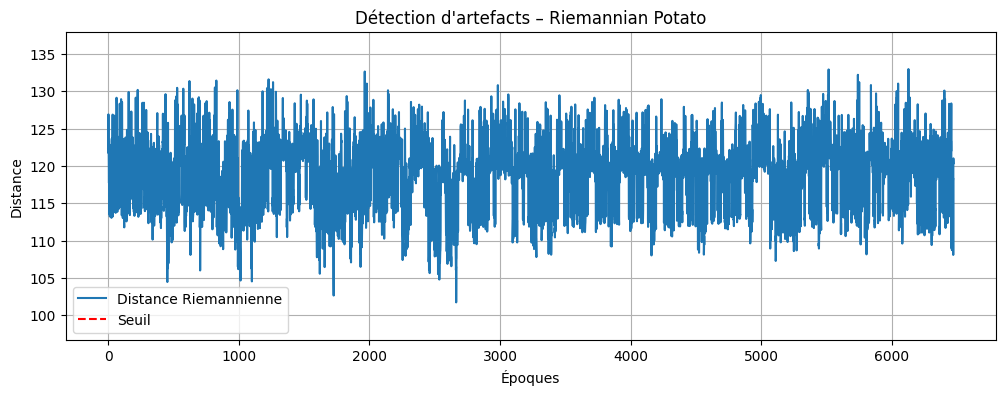

In [7]:
valid_distances = distances[np.isfinite(distances)]  # supprime NaN et Inf

plt.figure(figsize=(12, 4))
plt.plot(valid_distances, label="Distance Riemannienne")
plt.axhline(threshold, color="red", linestyle="--", label="Seuil")
plt.title("Détection d'artefacts – Riemannian Potato")
plt.xlabel("Époques")
plt.ylabel("Distance")
plt.grid()
plt.legend()

# Fixe les limites de l'axe Y autour des valeurs valides
plt.ylim(valid_distances.min() - 5, valid_distances.max() + 5)

plt.show()


In [8]:
# Nombre d'époques ignorées pour initialisation
n_init = len(epochs) - len(artifact_mask)

# Créer un masque global de la même taille que epochs
artifact_mask_full = np.zeros(len(epochs), dtype=bool)
artifact_mask_full[n_init:] = artifact_mask

# Temps des époques rejetées
artifact_times = epochs[artifact_mask_full].events[:, 0] / raw.info['sfreq']
duration = epochs.times[-1] - epochs.times[0]

# Annotations MNE
annotations = mne.Annotations(
    onset=artifact_times,
    duration=[duration] * len(artifact_times),
    description=['BAD_artifact'] * len(artifact_times)
)

# Appliquer au Raw
raw.set_annotations(annotations)


<RawEDF | 231024E-B.edf, 33 x 6846208 (26743.0 s), ~1.68 GiB, data loaded>

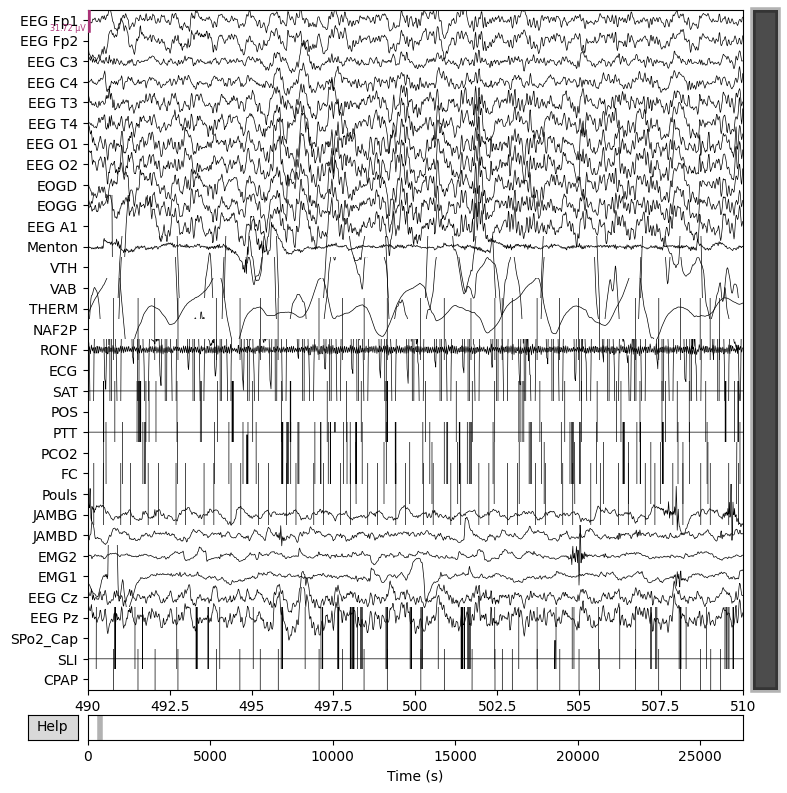

In [9]:

# Affichage
raw.plot(n_channels=35,start=490 ,duration= 20 , scalings='auto', show=False)
